# Получить кадры из видео для формирования данных для обучения.

In [58]:
from PIL import Image
import matplotlib.pyplot as plt

In [59]:
def get_positions(length, crop_size, step):
    positions = list(range(0, length - crop_size + 1, step))
    if positions[-1] != length - crop_size:
        positions.append(length - crop_size)
    return positions

def split_image(img_path, crop_size=640, step=320):
    img = Image.open(img_path)
    w, h = img.size

    crops = []
    x_positions = get_positions(w, crop_size, step)
    y_positions = get_positions(h, crop_size, step)

    for top in y_positions:
        for left in x_positions:
            box = (left, top, left + crop_size, top + crop_size)
            crop = img.crop(box)
            crops.append(crop)
    
    return img, crops

def show_crops_with_original(img, crops, cols=3):
    rows = (len(crops) + cols - 1) // cols
    
    # Создаем фигуру с двумя частями: верхняя для кусочков, нижняя для оригинала
    fig = plt.figure(figsize=(15, 4 + rows * 3))
    
    # Верхняя часть — разрезанные кусочки
    for i, crop in enumerate(crops):
        ax = fig.add_subplot(rows + 1, cols, i + 1)
        ax.imshow(crop)
        ax.axis('off')
    
    # Нижняя часть — оригинальное изображение на всю ширину, объединяем все колонки
    ax_orig = fig.add_subplot(rows + 1, 1, rows + 1)
    ax_orig.imshow(img)
    ax_orig.axis('off')
    
    plt.tight_layout()
    plt.show()

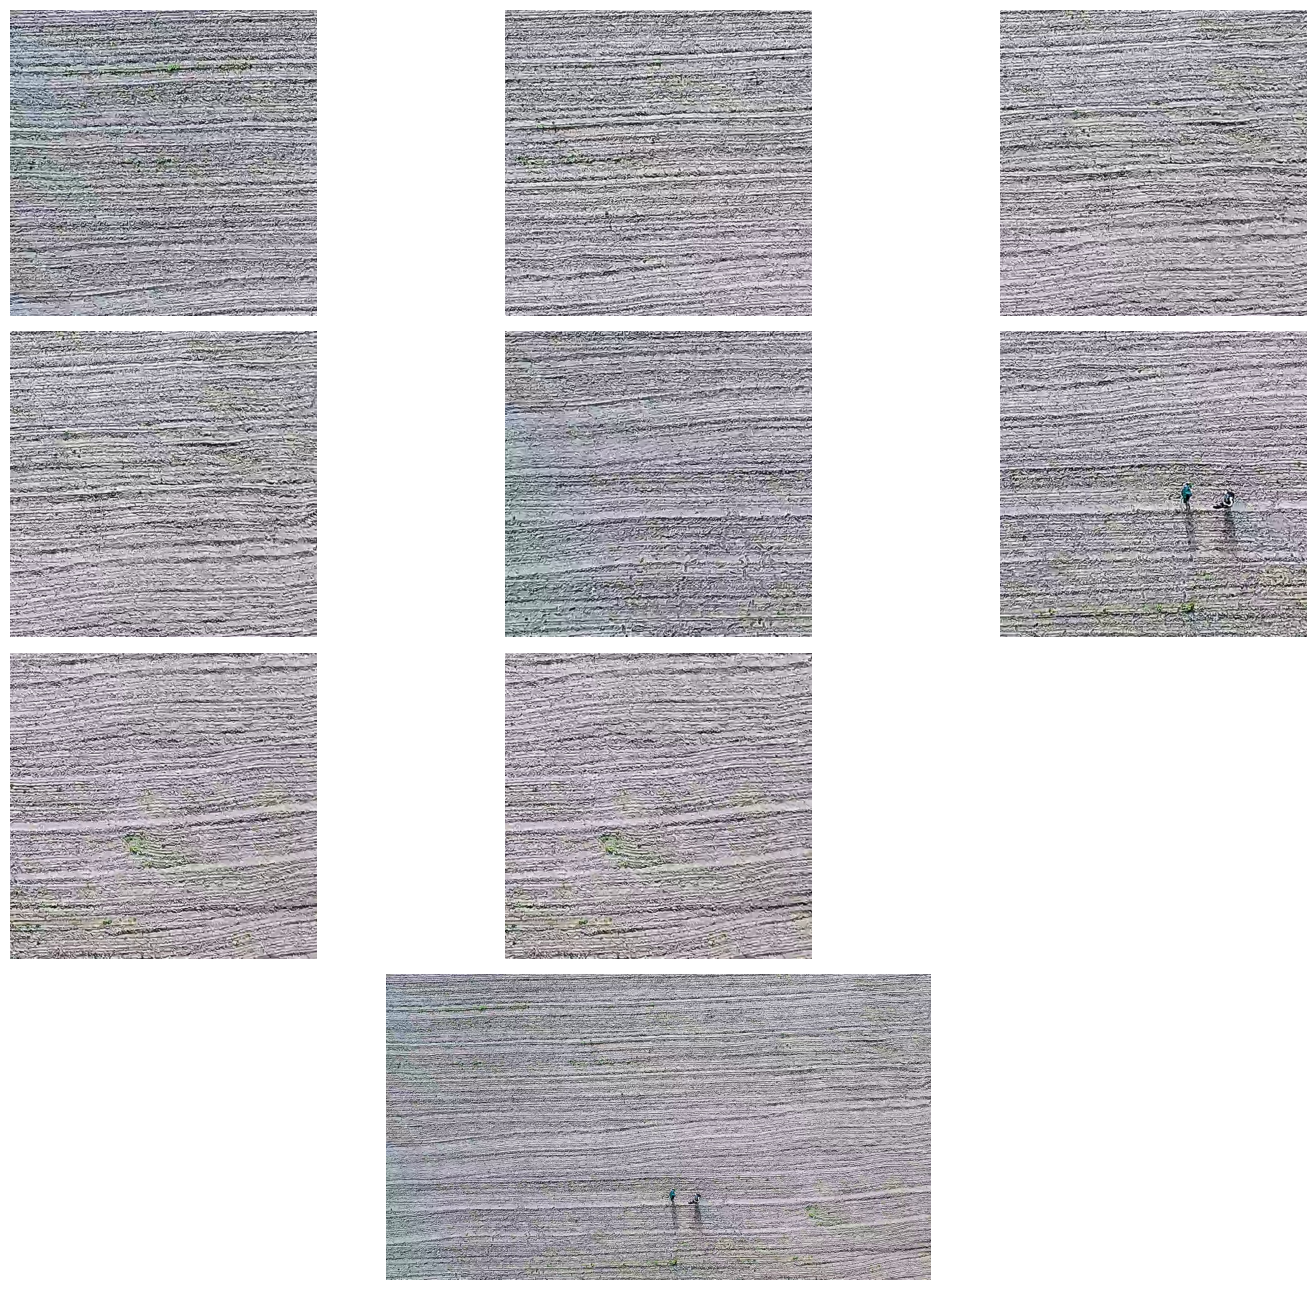

In [67]:
image_path = "../../DataSet/MyImg/frame_00005.jpg"

step = 620  # задаём шаг вручную, например 320

img, crops = split_image(image_path, crop_size=640, step=step)
show_crops_with_original(img, crops, cols=3)